# Nasdaq Analysis during War periods

## Background

This analysis examines whether major war periods have a measurable impact on the NASDAQ
Composite Index. Wars introduce geopolitical uncertainty, disrupt global trade, and affect
investor sentiment, all of which can influence equity markets. By analyzing four major
conflicts over the past 50 years, this study aims to determine whether war periods produce
returns that deviate significantly from historical norms.

Data is sourced from Yahoo Finance, covering 50 years of daily NASDAQ closing prices.
Average daily returns during each war period are compared against the 50-year historical
average using a two-tailed z-test.

## Hypothesis

Wars create uncertainty in financial markets, leading investors to reduce risk exposure.
This should result in lower average daily returns during war periods compared to the
historical average.

Specifically, we hypothesize that the average daily return of the NASDAQ Composite
during each war period will be significantly lower than the 50-year historical average,
as measured by a two-tailed z-test at a significance level of 0.05.

## Methodology

**Data**: NASDAQ Composite Index (^IXIC) sourced from Yahoo Finance, covering the past 50 years.
The NASDAQ is chosen as the primary index due to its concentration in technology and growth
stocks, which tend to be more sensitive to geopolitical uncertainty than other sectors.

**War Periods**: Four major wars are analyzed, each defined by their official start and end dates:
- Gulf War (1990-08-02 to 1991-02-28)
- Iraq War (2003-03-20 to 2011-12-15)
- War in Afghanistan (2001-10-07 to 2021-08-30)
- Russia-Ukraine War (2022-02-24 to present)

**Statistical Test**: A two-tailed z-test is applied for each war period, comparing the
average daily return during the war against the 50-year population mean and standard deviation.

**Null Hypothesis**: The average daily return during the war period is not significantly
different from the 50-year historical average.

**Significance Level**: 0.05

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats


In [21]:
nasdaq = yf.download("^IXIC", period="50y")
nasdaq.columns = nasdaq.columns.get_level_values(0)
nasdaq = nasdaq.reset_index()
nasdaq

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
0,1976-06-03,88.260002,88.260002,88.260002,88.260002,0
1,1976-06-04,87.750000,87.750000,87.750000,87.750000,0
2,1976-06-07,87.220001,87.220001,87.220001,87.220001,0
3,1976-06-08,87.120003,87.120003,87.120003,87.120003,0
4,1976-06-09,86.949997,86.949997,86.949997,86.949997,0
...,...,...,...,...,...,...
12598,2026-05-27,26674.730469,26715.310547,26538.310547,26695.439453,9240640000
12599,2026-05-28,26917.470703,26934.839844,26588.519531,26686.529297,9224620000
12600,2026-05-29,26972.619141,27094.800781,26859.269531,26960.839844,11906000000
12601,2026-06-01,27086.810547,27190.210938,26913.119141,26952.580078,10199240000


In [3]:
nasdaq["daily_return"] = nasdaq["Close"].pct_change()*100
nasdaq.head()

Price,Date,Close,High,Low,Open,Volume,daily_return
0,1976-06-03,88.260002,88.260002,88.260002,88.260002,0,NaN
1,1976-06-04,87.750000,87.750000,87.750000,87.750000,0,-0.577841
2,1976-06-07,87.220001,87.220001,87.220001,87.220001,0,-0.603987
3,1976-06-08,87.120003,87.120003,87.120003,87.120003,0,-0.114651
4,1976-06-09,86.949997,86.949997,86.949997,86.949997,0,-0.195140


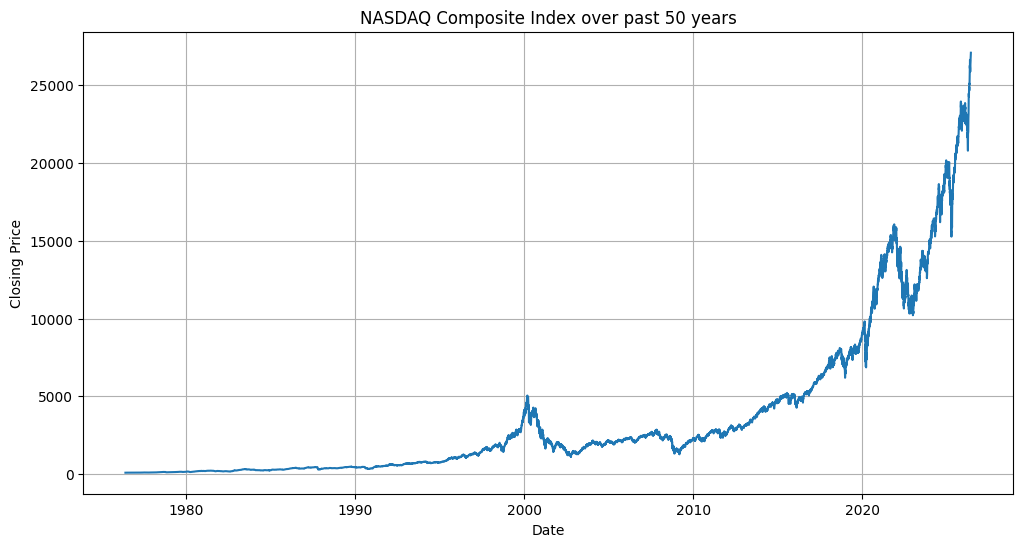

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(nasdaq["Date"], nasdaq["Close"])
plt.title("NASDAQ Composite Index over past 50 years")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid()

## Gulf War

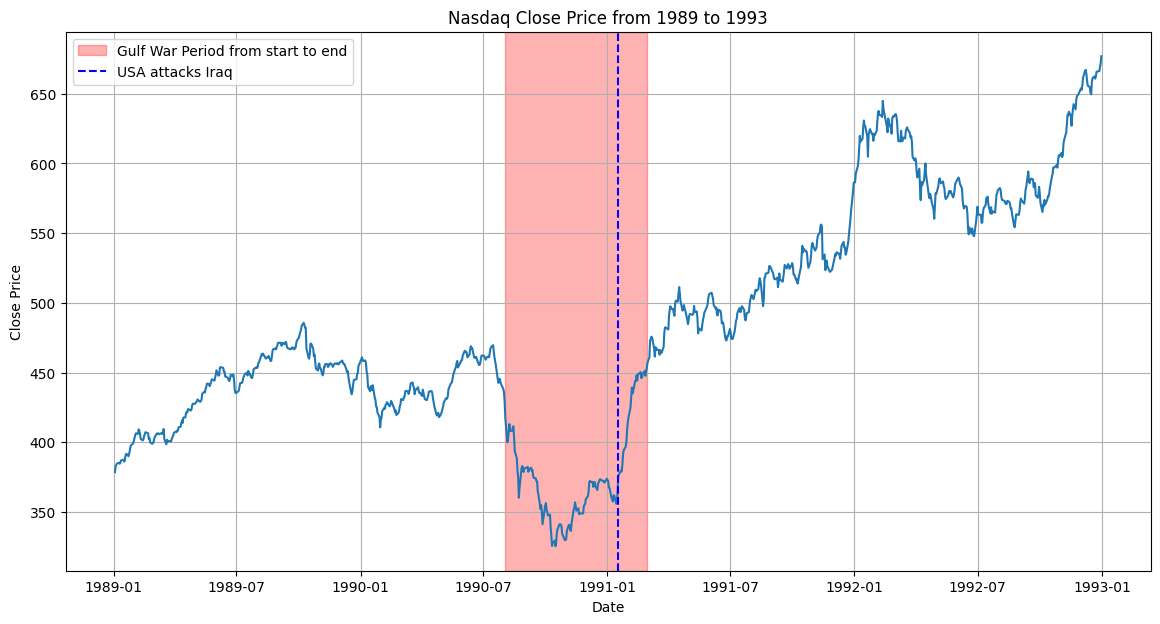

In [5]:
plt.figure(figsize=(14, 7))
mask = (nasdaq["Date"] >= "1989-01-01") & (nasdaq["Date"] <= "1993-01-01")
plt.plot(nasdaq[mask]["Date"], nasdaq[mask]["Close"])
plt.axvspan("1990-08-02", "1991-02-28", alpha=0.3, color="red", label="Gulf War Period from start to end")
plt.axvline(x = pd.to_datetime("1991-01-17"), color="blue", linestyle="--", label="USA attacks Iraq")
plt.legend()
plt.title("Nasdaq Close Price from 1989 to 1993")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid()
plt.show()

Gulf War Timeline

1990-08-02 — Iraq invades Kuwait
1990-08-07 — US deploys troops to Saudi Arabia (Operation Desert Shield)
1990-11-29 — UN issues ultimatum to Iraq: withdraw by 1991-01-15
1991-01-15 — UN deadline expires
1991-01-17 — US-led coalition launches air strikes on Iraq (Operation Desert Storm)
1991-02-24 — Ground offensive begins
1991-02-28 — Bush declares ceasefire, war ends

Analysis

The price of NASDAQ fell immediately after Iraq invades Kuwait. The reasons behind this include the rise of oil price, and uncertainty over whether and how the United States would intervene, and in the length it will continue.

The price of NASDAQ rose rapidly in 1991-01-17, when US-led coalition launched air strikes on Iraq. This event sparked optimism among investors, while also resolving uncertainties surrounding the war. 

In [6]:
avg_return = nasdaq["daily_return"].mean()
# The Gulf War occurred from August 2, 1990, to February 28, 1991. We will filter the data for this period and calculate the average return during the Gulf War.
gulf_war = nasdaq[(nasdaq["Date"] >= "1990-08-02") & (nasdaq["Date"] <= "1991-02-28")]
avg_gulf_return = gulf_war["daily_return"].mean()

print(f'The average return of Nasdaq of past 50 years is {avg_return :.2f}%')
print(f'The average return during Gulf War is {avg_gulf_return :.2f}%')

The average return of Nasdaq of past 50 years is 0.05%
The average return during Gulf War is 0.03%


In [7]:
# Perform a two tailed z-test to determine if the average return during the Gulf War is significantly different from the overall average return.
population_mean = avg_return
population_std = nasdaq["daily_return"].std()
sample_mean = avg_gulf_return
sample_size = len(gulf_war)
standard_error = population_std / (sample_size ** 0.5)
z_score = (sample_mean - population_mean) / standard_error
print(f'Standard Error: {standard_error}')
print(f'Z-score: {z_score}')
p_value_gulf = 2 * (1 - stats.norm.cdf(abs(z_score)))
print(f'P-value: {p_value_gulf}')
print(f'At a significance level of 0.05, we {"reject" if p_value_gulf < 0.05 else "fail to reject"} the null hypothesis of no difference in returns during the Gulf War compared to the overall average return.')

Standard Error: 0.10816065001316841
Z-score: -0.1777362698407693
P-value: 0.858930099515794
At a significance level of 0.05, we fail to reject the null hypothesis of no difference in returns during the Gulf War compared to the overall average return.


## Iraq War

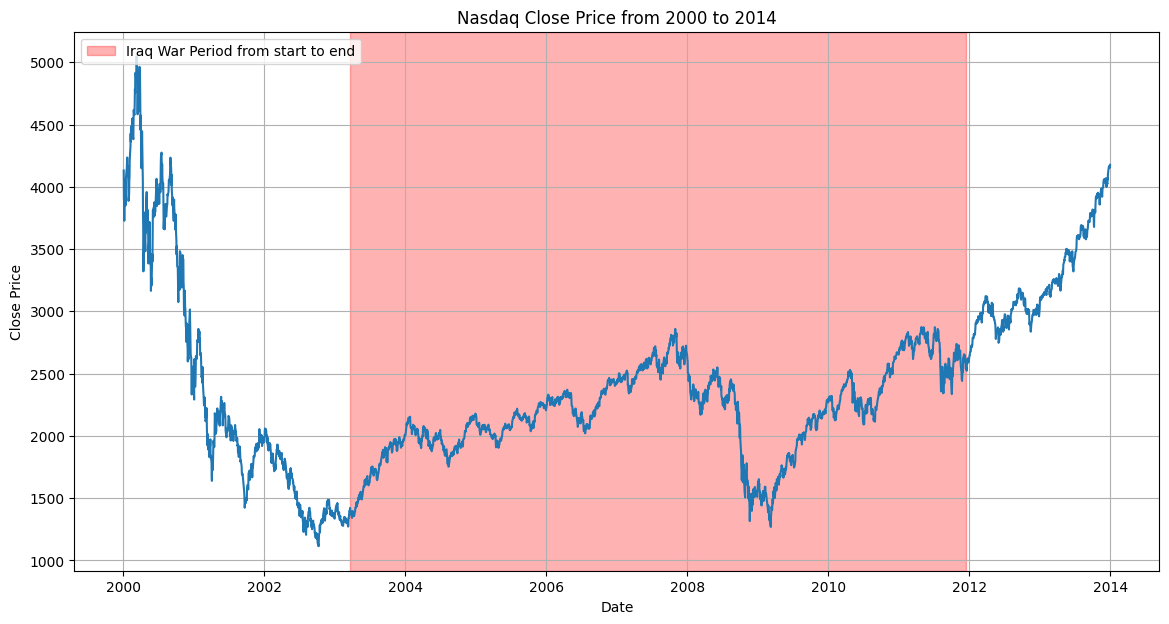

In [8]:
plt.figure(figsize=(14, 7))
mask = (nasdaq["Date"] >= "2000-01-01") & (nasdaq["Date"] <= "2014-01-01")
plt.plot(nasdaq[mask]["Date"], nasdaq[mask]["Close"])
plt.axvspan("2003-03-20", "2011-12-15", alpha=0.3, color="red", label="Iraq War Period from start to end")
plt.title("Nasdaq Close Price from 2000 to 2014")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend(loc = "upper left")
plt.grid()
plt.show()

Iraq War Timeline

2002-09-12 — Bush addresses UN, warns of Iraq threat
2002-10-16 — US Congress authorizes use of military force against Iraq
2003-02-05 — Colin Powell presents evidence of WMDs at UN
2003-03-17 — Bush issues 48-hour ultimatum to Saddam Hussein
2003-03-20 — US-led coalition invades Iraq
2003-04-09 — Baghdad falls, Saddam statue toppled
2003-05-01 — Bush declares "Mission Accomplished"
2008-09-15 — Lehman Brothers collapse (financial crisis begins)
2011-12-15 — US military formally withdraws from Iraq, war ends

Analysis

Even before the Iraq War was declared, the price of NASDAQ had already dropped approximately 75% from its previous peak, largely due to the collapse of the dot-com bubble, which heavily affected NASDAQ-listed tech stocks. On top of this, the impact of the war was already priced in by the market as early as September 2002, when Bush addressed the UN and warned of the Iraq threat, causing uncertainty to rise ahead of the official declaration.

Due to overlapping impact of dot-com bubble and Lehman Brothers crisis, isolating the impact of Iraq war on NASDAQ is difficult.

In [9]:
iraq_war = nasdaq[(nasdaq["Date"] >= "2003-03-20") & (nasdaq["Date"] <= "2011-12-15")]
avg_iraq_return = iraq_war["daily_return"].mean()
print (f"The average return of Nasdaq of past 50 years is {avg_return :.2f}%")
print(f"The average return during Iraq War is {avg_iraq_return :.2f}%")

The average return of Nasdaq of past 50 years is 0.05%
The average return during Iraq War is 0.04%


In [10]:
# Perform a two tailed z-test to determine if the average return during the Iraq War is significantly different from the overall average return.
population_mean = avg_return
population_std = nasdaq["daily_return"].std()
sample_mean = avg_iraq_return
sample_size = len(iraq_war)
standard_error = population_std / (sample_size ** 0.5)
z_score = (sample_mean - population_mean) / standard_error
print(f'Standard Error: {standard_error}')
print(f'Z-score: {z_score}')
p_value_iraq = 2 * (1 - stats.norm.cdf(abs(z_score)))
print(f'P-value: {p_value_iraq}')
print(f'At a significance level of 0.05, we {"reject" if p_value_iraq < 0.05 else "fail to reject"} the null hypothesis of no difference in returns during the Iraq War compared to the overall average return.')

Standard Error: 0.027838121204863817
Z-score: -0.5744890861604802
P-value: 0.5656368838351442
At a significance level of 0.05, we fail to reject the null hypothesis of no difference in returns during the Iraq War compared to the overall average return.


## War in Afghanistan

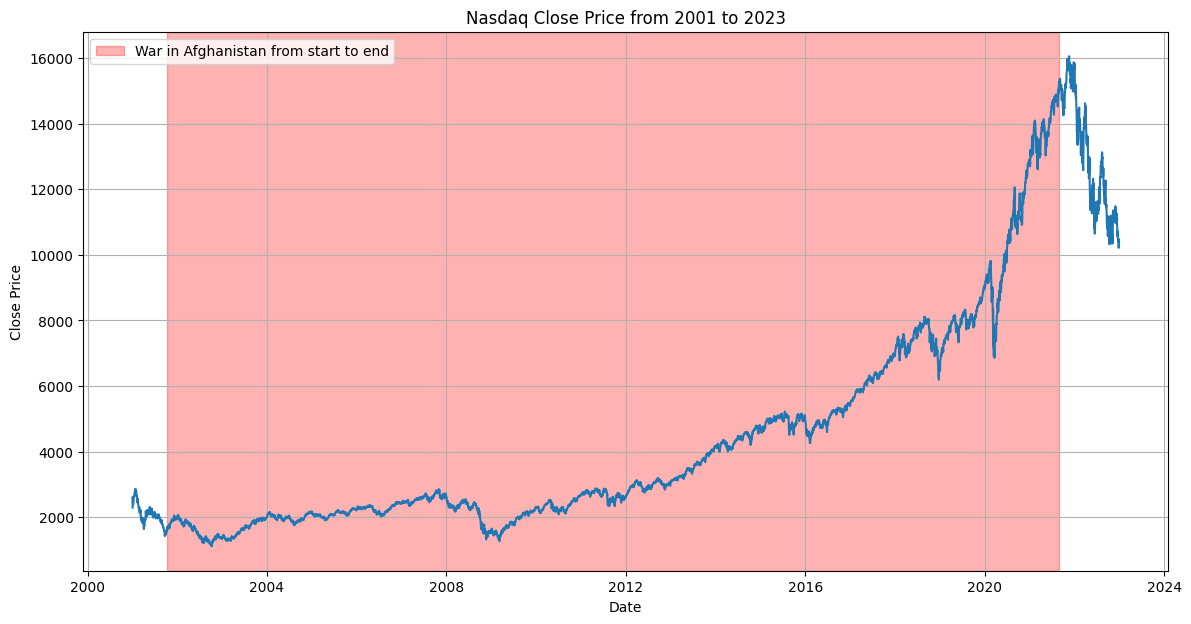

In [11]:
plt.figure(figsize=(14, 7))
mask = (nasdaq["Date"] >= "2001-01-01" ) & (nasdaq["Date"] <= "2023-01-01")
plt.plot(nasdaq[mask]["Date"], nasdaq[mask]["Close"])
plt.axvspan("2001-10-07", "2021-08-30", alpha=0.3, color="red", label="War in Afghanistan from start to end")
plt.title("Nasdaq Close Price from 2001 to 2023")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend(loc = "upper left")
plt.grid()
plt.show()

The period between the start and end of the war spanned around 20 years. This length of a term makes it difficult to visualize the impact of the war on NASDAQ as resolution of uncertainty affects relatively short length of time, and many different factors got envolved over such a long timeframe.

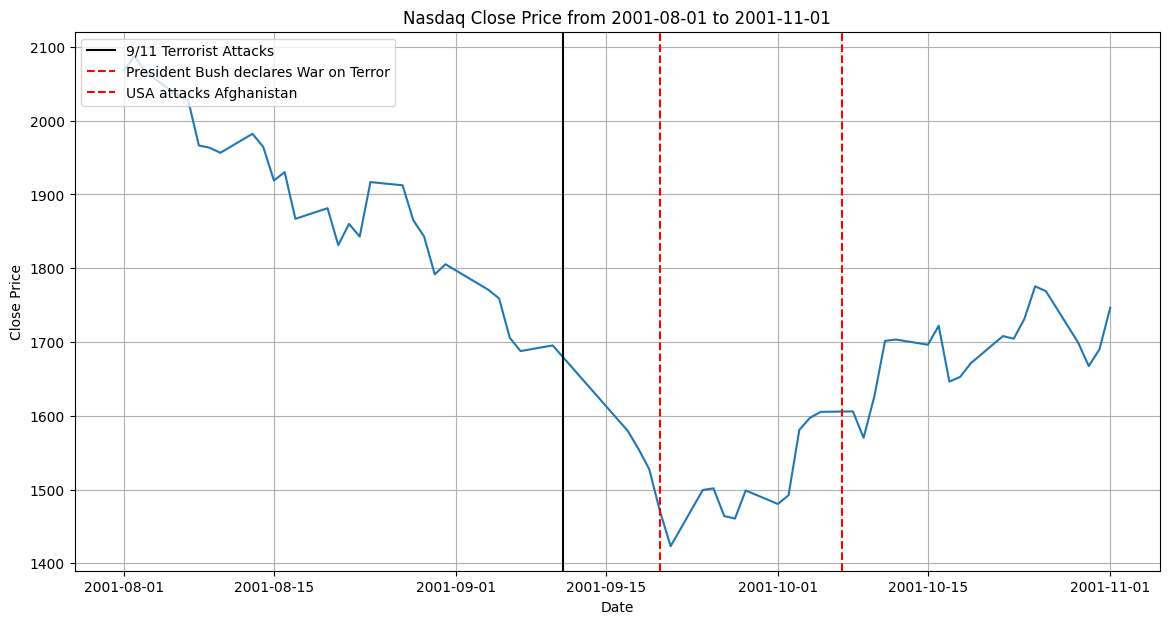

In [12]:
plt.figure(figsize=(14, 7))
mask = (nasdaq["Date"] >= "2001-08-01") & (nasdaq["Date"] <= "2001-11-01")
plt.plot(nasdaq[mask]["Date"], nasdaq[mask]["Close"])
plt.axvline(x = pd.to_datetime("2001-09-11"), color = "black" ,label="9/11 Terrorist Attacks")
plt.axvline(x = pd.to_datetime("2001-09-20"), color = "red", linestyle = "--", label="President Bush declares War on Terror")
plt.axvline(x = pd.to_datetime("2001-10-07"), color = "red", linestyle = "--", label="USA attacks Afghanistan")

plt.title("Nasdaq Close Price from 2001-08-01 to 2001-11-01")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend(loc = "upper left")
plt.grid()
plt.show()

Afghanistan War Timeline

2001-09-11 — Al-Qaeda terrorist attacks on US soil (9/11)
2001-09-20 — Bush declares War on Terror, issues ultimatum to Taliban
2001-10-07 — US-led coalition invades Afghanistan (Operation Enduring Freedom)
2001-11-13 — Taliban regime falls, Kabul captured
2009-02-17 — Obama approves troop surge
2011-05-02 — Osama bin Laden killed in Pakistan
2014-12-28 — US formally ends combat mission
2021-08-15 — Taliban retakes Kabul
2021-08-30 — US completes full military withdrawal, war ends

Analysis

In 2001-09-11, 9/11 Terror attack occured. This incident made NASDAQ to fall rapidly, and escalated uncertainties for investors. 

After president Bush declared War on Terror in 2001-09-20, the uncertainty was highly resolved, and when US attacked Afghanistan in 2001-10-07, the uncertainty caused by the war was mostly resolved.


In [13]:
# 
afghan_war = nasdaq[(nasdaq["Date"] >= "2001-09-20") & (nasdaq["Date"] <= "2021-08-30")]
avg_afghan_return = afghan_war["daily_return"].mean()
print (f"The average return of Nasdaq of past 50 years is {avg_return :.2f}%")
print(f"The average return during Russia-Ukraine War is {avg_afghan_return :.2f}%")

The average return of Nasdaq of past 50 years is 0.05%
The average return during Russia-Ukraine War is 0.06%


In [14]:
population_mean = avg_return
population_std = nasdaq["daily_return"].std()
sample_mean = avg_afghan_return
sample_size = len(afghan_war)
standard_error = population_std / (sample_size ** 0.5)
z_score = (sample_mean - population_mean) / standard_error
print(f'Standard Error: {standard_error}')
print(f'Z-score: {z_score}')
p_value_afghan = 2 * (1 - stats.norm.cdf(abs(z_score)))
print(f'P-value: {p_value_afghan}')
print(f'At a significance level of 0.05, we {"reject" if p_value_afghan < 0.05 else "fail to reject"} the null hypothesis of no difference in returns during the Afghanistan War compared to the overall average return.')

Standard Error: 0.018443808561607766
Z-score: 0.0903239760440702
P-value: 0.9280297678934246
At a significance level of 0.05, we fail to reject the null hypothesis of no difference in returns during the Afghanistan War compared to the overall average return.


## Russia-Ukraine War (Ongoing)

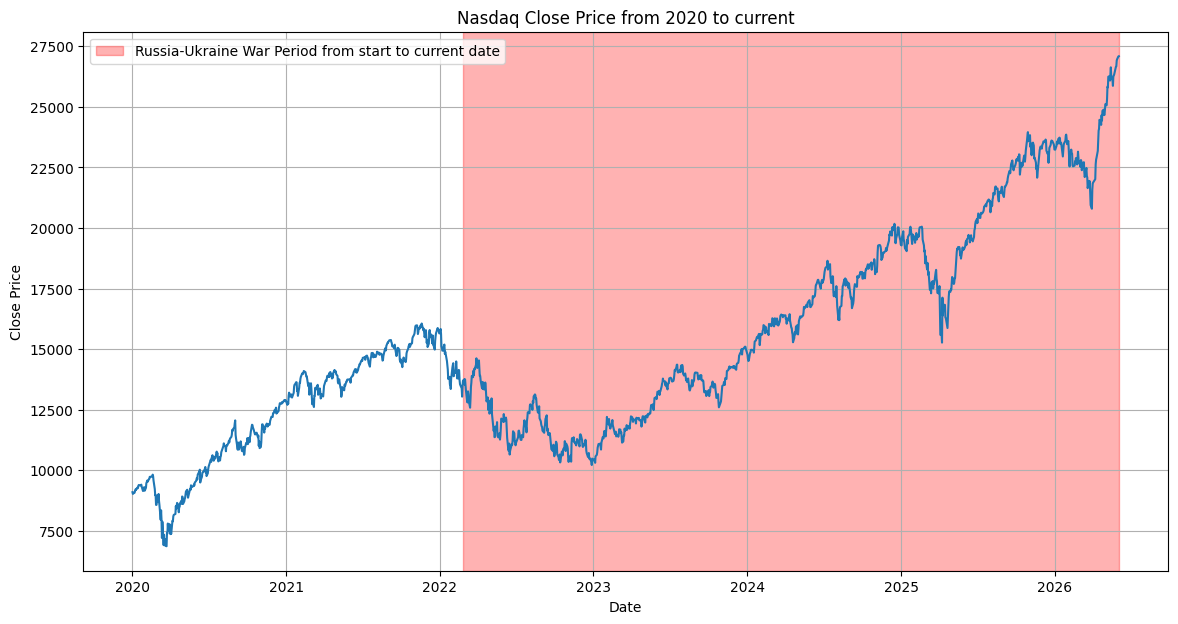

In [15]:
plt.figure(figsize=(14, 7))
mask = (nasdaq["Date"] >= "2020-01-01")
plt.plot(nasdaq[mask]["Date"], nasdaq[mask]["Close"])
plt.axvspan("2022-02-24", nasdaq["Date"].max(), alpha=0.3, color="red", label="Russia-Ukraine War Period from start to current date")
plt.title("Nasdaq Close Price from 2020 to current")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend(loc = "upper left")
plt.grid()
plt.show()

Russia-Ukraine War Timeline

2022-02-24 — Russia launches full-scale invasion of Ukraine
2022-02-26 — Russia removed from SWIFT international banking system
2022-03-08 — US bans Russian oil imports
2022-09-06 — Ukraine launches Kharkiv counteroffensive, recaptures significant territory
2023-06-04 — Ukraine launches major counteroffensive (largely unsuccessful)
2024-11-05 — Trump re-elected, raising hopes for ceasefire negotiations
2025-03 — US-brokered ceasefire talks begin

Analysis

After the invasion in 2022-02-24, NASDAQ reacted immediately downward. As war continued for a long period of time, the market became stable and moved onto an ignoring phase. The point where uncertainty became fully resolved is unclear as the war is still ongoing.


In [16]:
# The Russia-Ukraine War started on February 24, 2022, and is ongoing. We will filter the data from this date to the current date and calculate the average return during this period.
rus_war = nasdaq[(nasdaq["Date"] >= "2022-02-24")]
avg_rus_return = rus_war["daily_return"].mean()
print (f"The average return of Nasdaq of past 50 years is {avg_return :.2f}%")
print(f"The average return during Russia-Ukraine War is {avg_rus_return :.2f}%")

The average return of Nasdaq of past 50 years is 0.05%
The average return during Russia-Ukraine War is 0.08%


In [17]:
# Perform a two tailed z-test to determine if the average return during the Russia-Ukraine War is significantly different from the overall average return.
population_mean = avg_return
population_std = nasdaq["daily_return"].std()
sample_mean = avg_rus_return
sample_size = len(rus_war)
standard_error = population_std / (sample_size ** 0.5)
z_score = (sample_mean - population_mean) / standard_error
print(f'Standard Error: {standard_error}')
print(f'Z-score: {z_score}')
p_value_rus = 2 * (1 - stats.norm.cdf(abs(z_score)))
print(f'P-value: {p_value_rus}')
print(f'At a significance level of 0.05, we {"reject" if p_value_rus < 0.05 else "fail to reject"} the null hypothesis of no difference in returns during the Russia-Ukraine War compared to the overall average return.')

Standard Error: 0.03993475101702016
Z-score: 0.6193657017480303
P-value: 0.5356754706565405
At a significance level of 0.05, we fail to reject the null hypothesis of no difference in returns during the Russia-Ukraine War compared to the overall average return.


# Results

In [18]:
print(
    f'The p-value for the Gulf War is {p_value_gulf:.4f},\n'
    f'for the Iraq War is {p_value_iraq:.4f},\n'
    f'for the Afghanistan War is {p_value_afghan:.4f},\n'
    f'and for the Russia-Ukraine War is {p_value_rus:.4f}. \n\n'
    f'The significance level of 0.05 is used to determine whether to reject the null hypothesis of no difference in returns during each war compared to the overall average return.'
)

The p-value for the Gulf War is 0.8589,
for the Iraq War is 0.5656,
for the Afghanistan War is 0.9280,
and for the Russia-Ukraine War is 0.5357. 

The significance level of 0.05 is used to determine whether to reject the null hypothesis of no difference in returns during each war compared to the overall average return.


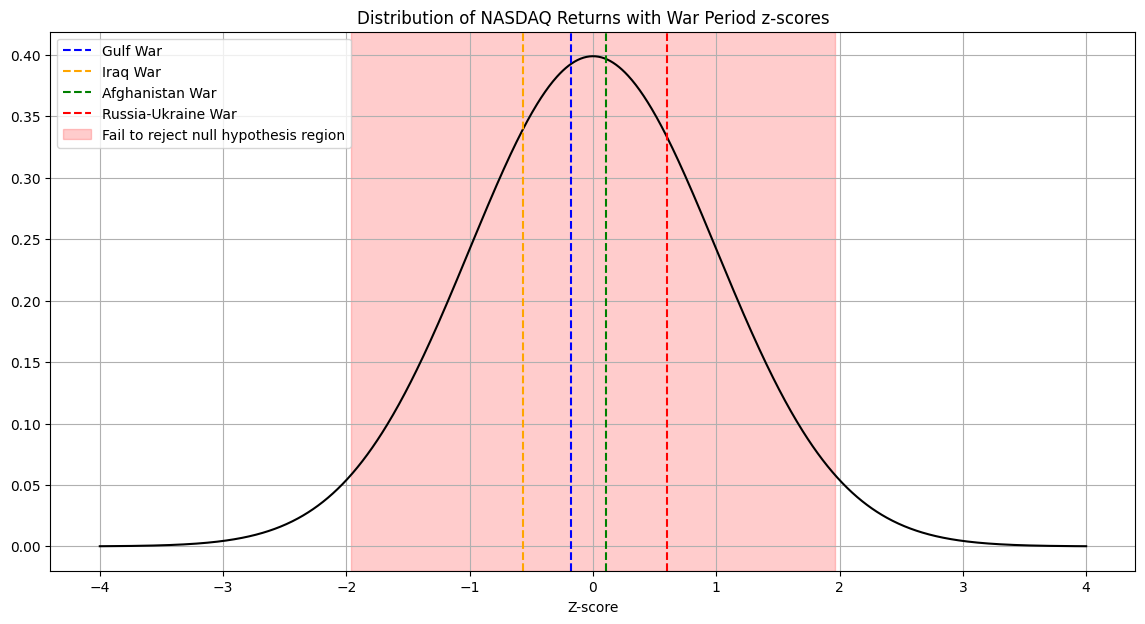

In [19]:
import numpy as np

x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x)

plt.figure(figsize=(14, 7))
plt.plot(x, y, color="black")

plt.axvline(x=-0.1755, color="blue", linestyle = "--",label=f"Gulf War")
plt.axvline(x=-0.5657, color="orange", linestyle = "--",label=f"Iraq War")
plt.axvline(x=0.1038, color="green", linestyle = "--",label=f"Afghanistan War")
plt.axvline(x=0.6032, color="red", linestyle = "--",label=f"Russia-Ukraine War")

plt.axvspan(-1.96, 1.96, alpha=0.2, color="red", label="Fail to reject null hypothesis region")

plt.title("Distribution of NASDAQ Returns with War Period z-scores")
plt.xlabel("Z-score")
plt.legend(loc = "upper left")
plt.grid()
plt.show()


## Analysis

### 1. Why are the results not statistically significant?

Across all four wars analyzed, the z-test failed to reject the null hypothesis, suggesting that war periods did not significantly affect NASDAQ returns compared to usual average returns. There are several reasons that I assume why this result came out. 

First, war durations being too long. The Iraq War lasted 8 years and the Afghanistan War spanned 20 years, which made it difficult to isolate the effect of war from other macroeconomic factors such as the dot-com bubble collapse, the 2008 financial crisis, and the post-pandemic AI boom.

Secondly, sometimes, the market reacts even before the war is declared. For example, in the Iraq War, the market had already priced in the impact of the war as early as September 2002, when Bush addressed the UN and warned of the Iraq threat — months before the official invasion in March 2003. Similarly, in the Afghanistan War, NASDAQ began to rebound on September 20, 2001, when President Bush declared the War on Terror — over two weeks before the actual invasion on October 7.

### Limitations

Additionally, NASDAQ's heavy concentration in technology stocks makes it particularly sensitive to tech-sector events, which are largely unrelated to geopolitical conflicts. This further dilutes the measurable impact of war on the index. (Ex. Dot-com bubble)

### Improvements & Pt. 2

Rather than analyzing war periods as a whole, a more meaningful approach may be to focus on "uncertainty."
Events that significantly resolves each conflict, the moments where investor sentiment shifts decisively. This will be explored in Part 2 using the S&P 500, which provides a broader representation of the US economy.